In [1]:
# Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [5]:
df = pd.read_csv('data/student_performance.csv')
print(df.shape)
df.head()

(2392, 15)


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [6]:
# Basic dataset info
print("Dataset Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Statistics:")
df.describe()

Dataset Shape: (2392, 15)

Column Names: ['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA', 'GradeClass']

Missing Values:
StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64

Basic Statistics:


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
count,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,2196.500000,16.468645,0.510870,0.877508,1.746237,9.771992,14.541388,0.301421,2.122074,0.383361,0.303512,0.196906,0.157191,1.906186,2.983696
std,690.655244,1.123798,0.499986,1.028476,1.000411,5.652774,8.467417,0.458971,1.122813,0.486307,0.459870,0.397744,0.364057,0.915156,1.233908
min,1001.000000,15.000000,0.000000,0.000000,0.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1598.750000,15.000000,0.000000,0.000000,1.000000,5.043079,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.174803,2.000000
50%,2196.500000,16.000000,1.000000,0.000000,2.000000,9.705363,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.893393,4.000000
75%,2794.250000,17.000000,1.000000,2.000000,2.000000,14.408410,22.000000,1.000000,3.000000,1.000000,1.000000,0.000000,0.000000,2.622216,4.000000
max,3392.000000,18.000000,1.000000,3.000000,4.000000,19.978094,29.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,4.000000,4.000000


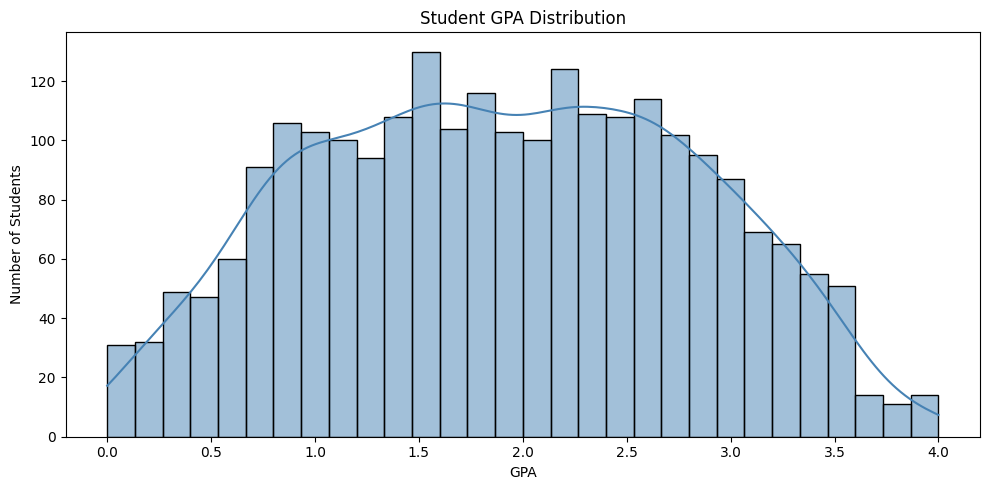

✅ GPA Distribution plotted!


In [7]:
# GPA Distribution
plt.figure(figsize=(10,5))
sns.histplot(df['GPA'], bins=30, kde=True, color='steelblue')
plt.title('Student GPA Distribution')
plt.xlabel('GPA')
plt.ylabel('Number of Students')
plt.tight_layout()
plt.savefig('gpa_distribution.png')  # saves graph for GitHub
plt.show()
print("✅ GPA Distribution plotted!")

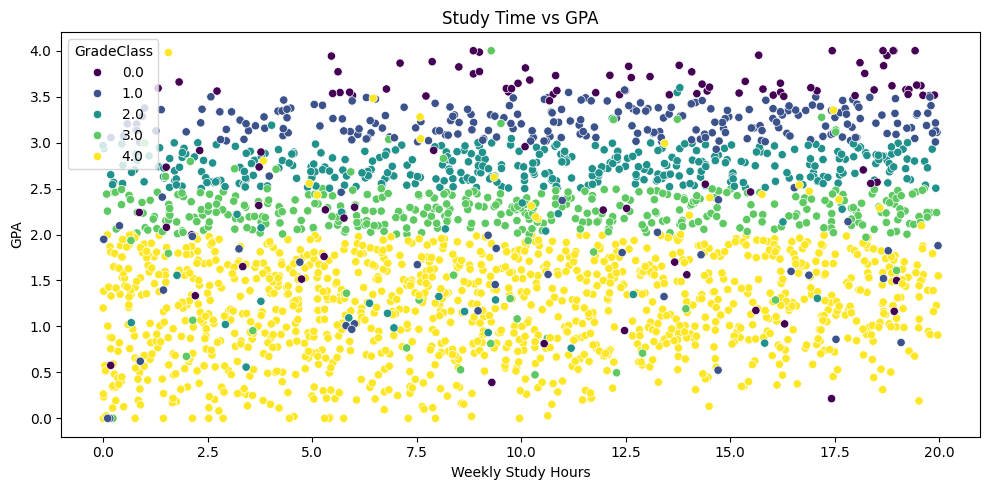

✅ Study Time vs GPA plotted!


In [8]:
# Study Time vs GPA
plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x='StudyTimeWeekly', y='GPA', hue='GradeClass', palette='viridis')
plt.title('Study Time vs GPA')
plt.xlabel('Weekly Study Hours')
plt.ylabel('GPA')
plt.tight_layout()
plt.savefig('studytime_vs_gpa.png')
plt.show()
print("✅ Study Time vs GPA plotted!")

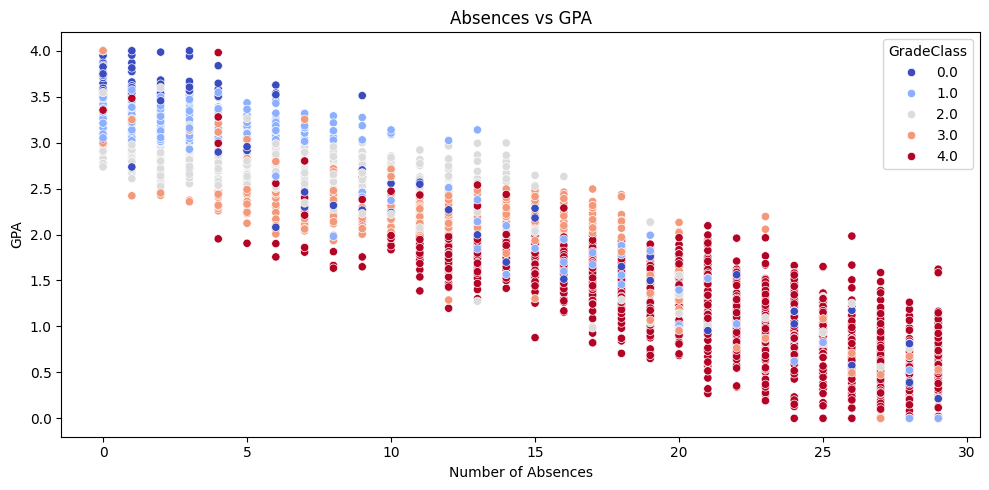

✅ Absences vs GPA plotted!


In [9]:
# Absences vs GPA
plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x='Absences', y='GPA', hue='GradeClass', palette='coolwarm')
plt.title('Absences vs GPA')
plt.xlabel('Number of Absences')
plt.ylabel('GPA')
plt.tight_layout()
plt.savefig('absences_vs_gpa.png')
plt.show()
print("✅ Absences vs GPA plotted!")

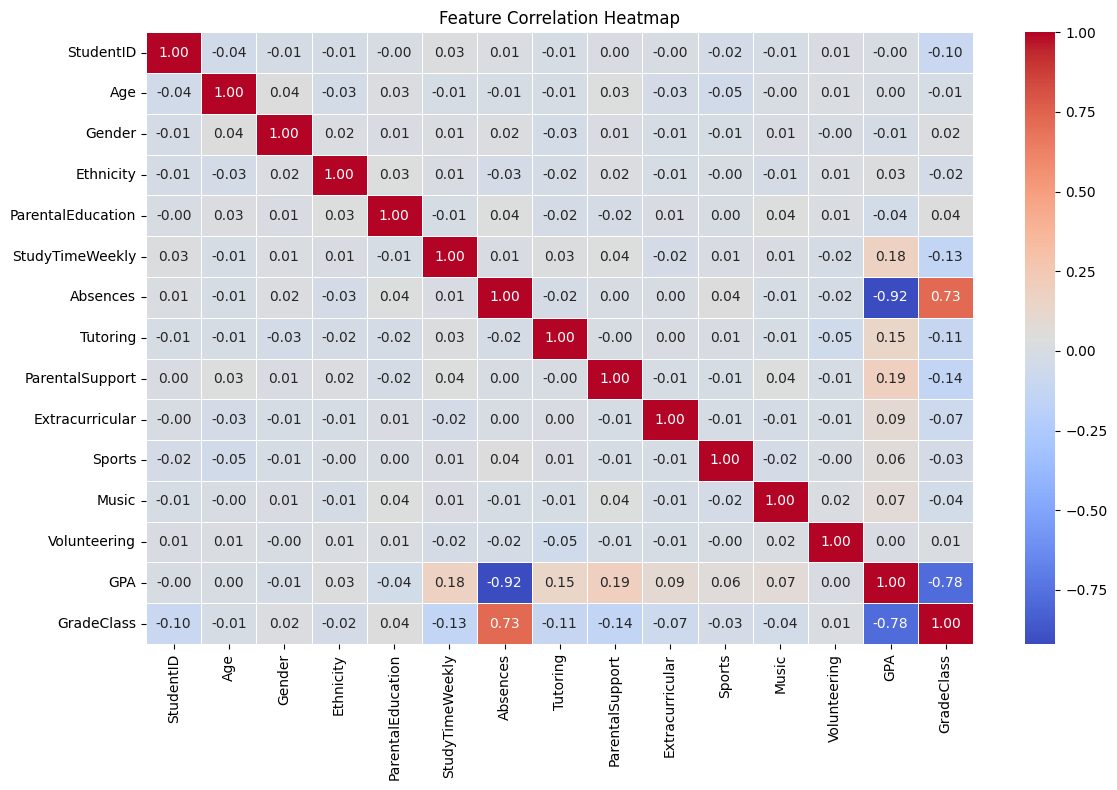

✅ Heatmap plotted!


In [10]:
# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()
print("✅ Heatmap plotted!")

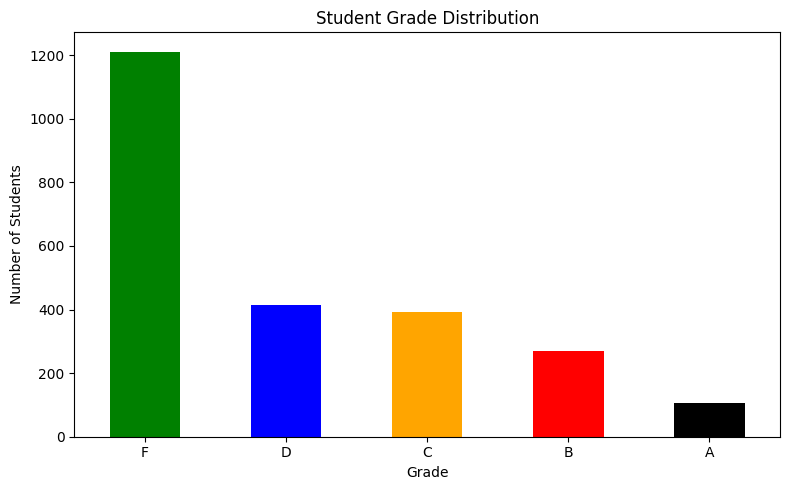

✅ Grade Distribution plotted!


In [11]:
# Grade Distribution
plt.figure(figsize=(8,5))
grade_labels = {0:'A', 1:'B', 2:'C', 3:'D', 4:'F'}
df['GradeClass'].map(grade_labels).value_counts().plot(
    kind='bar', 
    color=['green','blue','orange','red','black']
)
plt.title('Student Grade Distribution')
plt.xlabel('Grade')
plt.ylabel('Number of Students')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('grade_distribution.png')
plt.show()
print("✅ Grade Distribution plotted!")

In [12]:
# Prepare data for ML
X = df[['Age', 'StudyTimeWeekly', 'Absences', 'Tutoring', 
         'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering']]
y = df['GradeClass']

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("✅ Data Split Done!")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

✅ Data Split Done!
Training samples: 1913
Testing samples: 479


In [16]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Model Trained!")
print(f"Model Accuracy: {accuracy*100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred, 
      target_names=['A','B','C','D','F']))

✅ Model Trained!
Model Accuracy: 70.35%

Detailed Report:
              precision    recall  f1-score   support

           A       0.67      0.18      0.29        22
           B       0.50      0.55      0.52        49
           C       0.55      0.49      0.52        85
           D       0.52      0.47      0.49        86
           F       0.85      0.95      0.89       237

    accuracy                           0.70       479
   macro avg       0.62      0.53      0.54       479
weighted avg       0.69      0.70      0.69       479



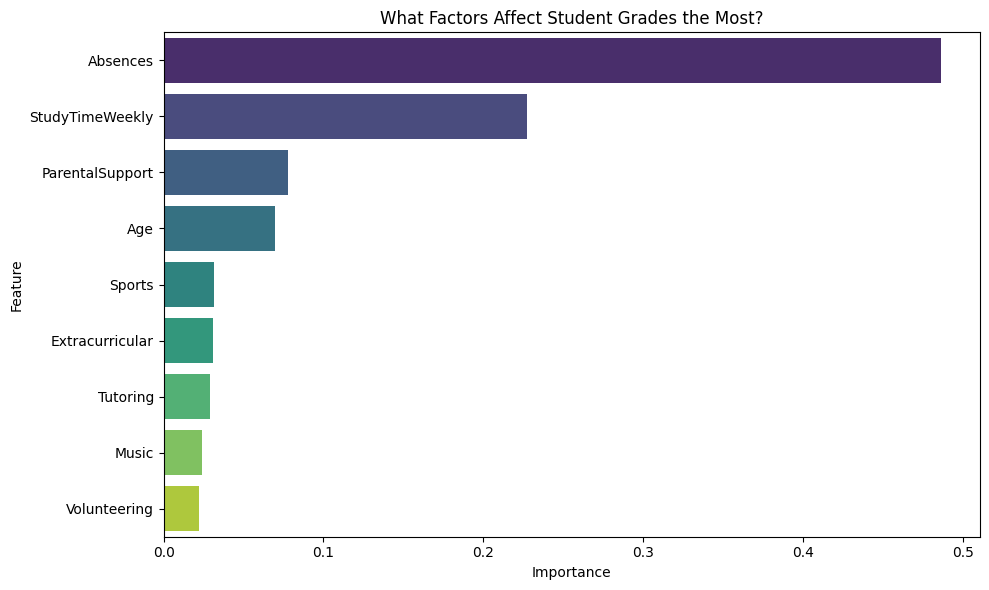

✅ Feature Importance plotted!


In [17]:
# Which factors affect grades the most?
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='viridis')
plt.title('What Factors Affect Student Grades the Most?')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()
print("✅ Feature Importance plotted!")


In [18]:
# Predict grade for a new student
new_student = pd.DataFrame({
    'Age': [17],
    'StudyTimeWeekly': [15],
    'Absences': [5],
    'Tutoring': [1],
    'ParentalSupport': [2],
    'Extracurricular': [1],
    'Sports': [0],
    'Music': [1],
    'Volunteering': [0]
})

prediction = model.predict(new_student)
grade_labels = {0:'A', 1:'B', 2:'C', 3:'D', 4:'F'}
print(f"✅ Predicted Grade: {grade_labels[prediction[0]]}")

✅ Predicted Grade: B


In [19]:
import joblib

# Save the trained model
joblib.dump(model, 'student_performance_model.pkl')
print("✅ Model saved as student_performance_model.pkl")

✅ Model saved as student_performance_model.pkl


In [20]:
# Final Summary
print("=" * 50)
print("   STUDENT PERFORMANCE ANALYSIS SYSTEM")
print("=" * 50)
print(f"✅ Total Students Analyzed: {len(df)}")
print(f"✅ Features Used: {X.shape[1]}")
print(f"✅ Model Accuracy: {accuracy*100:.2f}%")
print(f"✅ Graphs Generated: 5")
print(f"✅ Model Saved: student_performance_model.pkl")
print("=" * 50)
print("Project Complete! 🎉")

   STUDENT PERFORMANCE ANALYSIS SYSTEM
✅ Total Students Analyzed: 2392
✅ Features Used: 9
✅ Model Accuracy: 70.35%
✅ Graphs Generated: 5
✅ Model Saved: student_performance_model.pkl
Project Complete! 🎉
